In [1]:
# Multi-Ticker BOS-Fib Scalping Research
#
# Runs NiftyBOSFibScalpStrategy on NSE equities, NIFTY index, and/or crypto.
# Data is loaded from local cache and fetched automatically if not present.
# Edit the Parameters cell below, then Run All.

In [2]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src' / 'intraday_research').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

REPO_ROOT

PosixPath('/home/rahul/trading2/trading_bot')

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython import get_ipython
from IPython.display import display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('load_ext', 'autoreload')
    ip.run_line_magic('autoreload', '2')

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

from intraday_research.analytics import build_backtest_summary, hourly_summary, strategy_summary
from intraday_research.backtester import BacktestConfig, IntradayBacktester
from intraday_research.costs import TransactionCostModel
from intraday_research.features import FeatureEngine
from intraday_research.provider import MarketDataProvider
from intraday_research.risk import RiskManager
from intraday_research.strategies import NiftyBOSFibScalpStrategy
from intraday_research.types import InstrumentSpec

## Parameters

Edit `SYMBOLS_CONFIG` and settings below, then **Run All**.

In [4]:
# ── SYMBOLS ──────────────────────────────────────────────────────────────────
SYMBOLS_CONFIG = {
#     'RELIANCE':  'equity',
#     'HDFCBANK':  'equity',
#     'TCS':       'equity',
#     'SBIN':      'equity',
#     'ICICIBANK': 'equity',
    # 'NIFTY50': 'index',
    'BTCUSDT': 'crypto',
    'ETHUSDT': 'crypto',
    'SOLUSDT': 'crypto',
}

START_DATE = '2026-01-01' #'2026-01-01'
END_DATE   = '2026-06-25' #'2026-06-25'

# ── STRATEGY ──────────────────────────────────────────────────────────────────
ENTRY_MODE = 'limit_618'   # 'limit_618' or 'zone_touch_confirmation'

# ── PARAMETER SWEEP ───────────────────────────────────────────────────────────
IMPULSE_PCT_SWEEP = [0.25, 0.30, 0.50, 0.75, 1.00]   # % of median price
STOP_BUFFER_PCT   = 0.009

# ── LOOKBACK (removes whole-period forward bias) ──────────────────────────────
# Reference median that scales min_impulse/stop is computed from the trailing
# LOOKBACK_DAYS trade_dates, FROZEN per day — NOT the whole backtest window.
LOOKBACK_DAYS     = 7

# ── SQUARE-OFF / SESSION policy ───────────────────────────────────────────────
#   dt_time(15, 30) → hard square-off daily at that IST time (NSE/BSE)   [default]
#   None            → 24h continuous, NO square-off (crypto — matches live)
from datetime import time as dt_time
# SQUARE_OFF  = dt_time(15, 30)   # NSE/BSE close (equity default — re-enable for NSE runs)
SQUARE_OFF    = None              # 24h continuous — crypto sweep matches the live bot
SESSION_START = dt_time(9, 15)    # NSE/BSE open (only used when SQUARE_OFF is a time)

# ── ENTRY FILL MODEL ──────────────────────────────────────────────────────────
#   int  → realistic: place a resting limit at fib_618 on the signal, fill only on
#          a touch within the next N bars, else EXPIRE (matches the live bot).
#   None → optimistic: fill every signal on the confirmation bar (legacy).
ENTRY_MAX_BARS_WAIT = 3

#   1.000 → target AT the BOS level                 Theoretical RR ≈ 1.48:1
#   1.272 → 127.2% Fib extension beyond BOS level   Theoretical RR ≈ 2.33:1
#   1.618 → 161.8% Fib extension beyond BOS level   Theoretical RR ≈ 3.23:1
TARGET_EXT_SWEEP  = [1.0, 1.272, 1.618]

# ── TRAILING STOP ─────────────────────────────────────────────────────────────
USE_TRAILING_STOP = True

# ── TRADE SIZING ──────────────────────────────────────────────────────────────
# Equity: integer shares (NSE does not support fractional shares)
EQUITY_TRADE_VALUE_INR = 500_000   # auto-compute shares: floor(value / median_price)
EQUITY_FIXED_QTY       = 1
INDEX_LOTS             = 1

# Crypto: fractional units supported — qty = value / median_price (float)
# e.g. BTC @ $72,764  →  5000 / 72764 = 0.0687 BTC  (NOT forced to 1.0)
CRYPTO_TRADE_VALUE_USD = 5_000
CRYPTO_QTY             = 1.0      # fallback if CRYPTO_TRADE_VALUE_USD is None

# ── PARALLELISATION ───────────────────────────────────────────────────────────
import os
N_WORKERS = max(1, min(os.cpu_count() - 1, 8))   # leave one core free for the kernel

# ── FYERS AUTH ────────────────────────────────────────────────────────────────
FYERS_AUTH_FILE = 'fyers_auth.json'
FYERS_USER_KEY  = 'user1'

# ── COSTS ─────────────────────────────────────────────────────────────────────
from intraday_research.costs import EQUITY_COSTS, MEXC_ZERO_COSTS
# MEXC: marketable limit orders → 0% fee on ALL sides (maker rate applies).
#   Entry  = limit_618 order        → maker fee = 0%
#   Exits  = marketable limit order → fills at market price, still 0% maker fee
#   Result: net_pnl == gross_pnl  (no cost deduction for crypto runs)

OUTPUT_DIR = REPO_ROOT / 'artifacts' / 'multi_ticker_fib'


## Load Data

Data is loaded from local cache. Missing ranges are auto-fetched.

In [5]:
provider = MarketDataProvider(
    repo_root=REPO_ROOT,
    fyers_auth_file=FYERS_AUTH_FILE,
    fyers_user_key=FYERS_USER_KEY,
    verbose=True,
)

market_datasets: dict[str, pd.DataFrame] = {}

for sym, asset_type in SYMBOLS_CONFIG.items():
    try:
        print(f'Loading {sym} ({asset_type}) ...', end=' ', flush=True)
        df = provider.load(sym, asset_type, START_DATE, END_DATE)
        market_datasets[sym] = df
        print(f'{len(df):,} bars  [{df["trade_date"].min()} → {df["trade_date"].max()}]')
    except Exception as e:
        print(f'FAILED — {e}')

print(f'\nReady: {len(market_datasets)}/{len(SYMBOLS_CONFIG)} symbols loaded.')

Loading BTCUSDT (crypto) ... 252,813 bars  [2026-01-01 → 2026-06-25]
Loading ETHUSDT (crypto) ... 252,813 bars  [2026-01-01 → 2026-06-25]
Loading SOLUSDT (crypto) ... 253,110 bars  [2026-01-01 → 2026-06-25]

Ready: 3/3 symbols loaded.


## Run Backtests

In [6]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from datetime import time as dt_time

# ── Strategy variants ─────────────────────────────────────────────────────────
STRATEGY_VARIANTS = {
    'BASE':     (False, False),
    'VWAP':     (True,  False),
    'EMA':      (False, True),
    'VWAP_EMA': (True,  True),
}

# Equity: NSE intraday session
_EQUITY_FIRST_TRADE = pd.Timestamp('09:20').time()
_EQUITY_LAST_ENTRY  = pd.Timestamp('15:25').time()
_EQUITY_SESSION_END = dt_time(15, 30)

# Crypto: 24h session — no NSE restrictions
_CRYPTO_FIRST_TRADE = pd.Timestamp('00:00').time()
_CRYPTO_LAST_ENTRY  = pd.Timestamp('23:50').time()
_CRYPTO_SESSION_END = dt_time(23, 59)


def _resolve_quantity(df: pd.DataFrame, asset_type: str) -> float:
    if asset_type == 'index':
        return float(INDEX_LOTS)
    if asset_type == 'crypto':
        if CRYPTO_TRADE_VALUE_USD is not None:
            # Float division — 5000 / 72764 = 0.0687 BTC, not max(1, int(...))
            return round(CRYPTO_TRADE_VALUE_USD / float(df['close'].median()), 6)
        return float(CRYPTO_QTY)
    # Equity: integer shares only (NSE does not support fractional)
    if EQUITY_TRADE_VALUE_INR is not None:
        return float(max(1, int(EQUITY_TRADE_VALUE_INR / float(df['close'].median()))))
    return float(EQUITY_FIXED_QTY)


def _instrument_spec(asset_type: str) -> InstrumentSpec:
    if asset_type == 'index':
        return InstrumentSpec(quantity_mode='lots', lot_size=65, instrument_type='index')
    return InstrumentSpec(quantity_mode='units', lot_size=1, instrument_type='equity')


def _daily_ref_medians(df, lookback_days):
    """Reference median per trade_date = median of closes over the PREVIOUS
    `lookback_days` trade_dates (exclusive of the date itself). Lookahead-free;
    the first date falls back to its own closes."""
    import numpy as np
    by_date = {d: g['close'].to_numpy() for d, g in df.groupby('trade_date', sort=True)}
    dates = sorted(by_date)
    out = {}
    for i, d in enumerate(dates):
        prior = dates[max(0, i - lookback_days):i]
        pooled = np.concatenate([by_date[p] for p in prior]) if prior else by_date[d]
        out[str(d)] = float(np.median(pooled))
    return out


def _session_config(asset_type):
    """(first_trade, last_entry, session_end, continuous) for the run.
    Equities/index always use the NSE session. Crypto follows the SQUARE_OFF switch:
    a time -> hard square-off at that IST time; None -> 24h continuous (no square-off)."""
    if asset_type != 'crypto':
        return _EQUITY_FIRST_TRADE, _EQUITY_LAST_ENTRY, _EQUITY_SESSION_END, False
    if SQUARE_OFF is None:
        return dt_time(0, 0), dt_time(23, 59), dt_time(23, 59), True
    from datetime import datetime as _dt, timedelta as _td
    last_entry = (_dt(2000, 1, 1, SQUARE_OFF.hour, SQUARE_OFF.minute) - _td(minutes=5)).time()
    return SESSION_START, last_entry, SQUARE_OFF, False


def run_one(
    sym: str, market_data: pd.DataFrame, asset_type: str,
    variant: str, use_vwap: bool, use_ema: bool,
    min_impulse_pct: float, target_ext: float = 1.0,
) -> dict:
    # ── Session policy (SQUARE_OFF switch) ────────────────────────────────────
    is_crypto = (asset_type == 'crypto')
    first_trade, last_entry, session_end, continuous = _session_config(asset_type)
    if continuous:
        # Key the day in UTC so the strategy's per-day reset matches the 24/7 live bot.
        market_data = market_data.copy()
        market_data['timestamp']  = market_data['timestamp'].dt.tz_convert('UTC')
        market_data['trade_date'] = market_data['timestamp'].dt.date.astype(str)

    # ── Daily-frozen lookback scaling (lookahead-free) ────────────────────────
    # Reference median for date D = median of closes over the previous
    # LOOKBACK_DAYS trade_dates (exclusive of D) — removes the whole-period
    # forward bias of a single median(market_data).
    ref_med_by_date     = _daily_ref_medians(market_data, LOOKBACK_DAYS)
    min_impulse_by_date = {d: round(m * min_impulse_pct / 100, 4)
                           for d, m in ref_med_by_date.items()}
    stop_buffer_by_date = {d: round(max(m * STOP_BUFFER_PCT / 100, 0.05), 4)
                           for d, m in ref_med_by_date.items()}
    # Warm-up: the first LOOKBACK_DAYS dates have an incomplete / self-referential
    # lookback window, so DISABLE entries on them (impulse threshold = inf) while still
    # using their closes in later days' medians. Trading starts once a full LOOKBACK_DAYS
    # of real history exists — removes the 1-day self-lookahead + partial-warmup bias.
    for d in sorted(ref_med_by_date)[:LOOKBACK_DAYS]:
        min_impulse_by_date[d] = float('inf')
    trading_dates = sorted(ref_med_by_date)[LOOKBACK_DAYS:]
    first_ref = ref_med_by_date[trading_dates[0]] if trading_dates else ref_med_by_date[sorted(ref_med_by_date)[0]]
    min_imp   = round(first_ref * min_impulse_pct / 100, 4)              # scalar fallback
    stop_buf  = round(max(first_ref * STOP_BUFFER_PCT / 100, 0.05), 4)
    if asset_type == 'crypto' and CRYPTO_TRADE_VALUE_USD is not None:
        quantity = round(CRYPTO_TRADE_VALUE_USD / first_ref, 6)          # sizing: lookahead-free
    else:
        quantity = _resolve_quantity(market_data, asset_type)
    data_sym = market_data['symbol'].iloc[0]

    time_exit_min = 60 if target_ext <= 1.0 else 90

    strategy = NiftyBOSFibScalpStrategy(
        name=f'BOS_FIB_{variant}',
        pivot_lookback=2, min_swing_points=2,
        fib_zone_low=0.50, fib_zone_high=0.618,
        stop_buffer_points=stop_buf, min_impulse_points=min_imp,
        max_hold_bars=15, max_trades_per_day=500,
        max_consecutive_losses_per_day=200,
        entry_mode=ENTRY_MODE, min_confirmation_rr=0.0,
        use_vwap_filter=use_vwap, use_ema_filter=use_ema,
        target_extension_ratio=target_ext,
        min_impulse_by_date=min_impulse_by_date,
        stop_buffer_by_date=stop_buffer_by_date,
    )

    # MEXC: 0% fee via marketable limit orders → net == gross for crypto
    cost_model = MEXC_ZERO_COSTS if is_crypto else EQUITY_COSTS
    engine = IntradayBacktester(
        strategies=[strategy], feature_engine=FeatureEngine(),
        risk_manager=RiskManager(max_positions=1, max_daily_loss=50_000, quantity_per_trade=quantity),
        cost_model=cost_model,
    )
    result = engine.run(
        market_data,
        BacktestConfig(
            output_dir=str(OUTPUT_DIR / sym / variant / f'imp{min_impulse_pct}_ext{target_ext}'),
            instrument_specs={data_sym: _instrument_spec(asset_type)},
            initial_capital=1_000_000, max_positions=1, max_daily_loss=50_000,
            quantity_per_trade=quantity, sizing_mode='fixed',
            first_trade_time=first_trade,
            last_entry_time=last_entry,
            session_end=session_end,
            time_exit_minutes=time_exit_min,
            force_square_off_minutes_before_close=1,
            use_trailing_stop=USE_TRAILING_STOP,
            continuous_session=continuous,
            entry_max_bars_wait=ENTRY_MAX_BARS_WAIT,
        ),
    )
    result['_sym']        = sym
    result['_variant']    = variant
    result['_asset_type'] = asset_type
    result['_min_imp']    = min_imp
    result['_imp_pct']    = min_impulse_pct
    result['_target_ext'] = target_ext
    result['_quantity']   = quantity
    # _market_data is NOT included — re-attached in the main process after
    # futures complete, to avoid pickling large DataFrames across processes.
    return result


# ── Sizing summary ─────────────────────────────────────────────────────────────
for sym, asset_type in SYMBOLS_CONFIG.items():
    if sym not in market_datasets:
        continue
    med      = float(market_datasets[sym]['close'].median())
    qty      = _resolve_quantity(market_datasets[sym], asset_type)
    currency = '$' if asset_type == 'crypto' else '₹'
    print(f'{sym:10s} ({asset_type})  median={currency}{med:>12,.2f}  qty={qty:.6g}  '
          f'notional≈{currency}{qty * med:,.0f}')

# ── Build full job list ────────────────────────────────────────────────────────
jobs = [
    (sym, market_datasets[sym], asset_type, variant, use_vwap, use_ema, imp_pct, target_ext)
    for sym, asset_type in SYMBOLS_CONFIG.items() if sym in market_datasets
    for variant, (use_vwap, use_ema) in STRATEGY_VARIANTS.items()
    for imp_pct in IMPULSE_PCT_SWEEP
    for target_ext in TARGET_EXT_SWEEP
]
total = len(jobs)
print(f'\nLaunching {total} runs on {N_WORKERS} workers …\n')

# ── Parallel execution ─────────────────────────────────────────────────────────
results: dict[str, dict[str, dict[float, dict[float, dict]]]] = {}
done = 0

with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(run_one, *j): j for j in jobs}
    for future in as_completed(futures):
        try:
            r = future.result()
            # Re-attach market_data here — avoids serialising it from workers
            r['_market_data'] = market_datasets[r['_sym']]
            (results
             .setdefault(r['_sym'], {})
             .setdefault(r['_variant'], {})
             .setdefault(r['_imp_pct'], {})[r['_target_ext']]) = r
            s = build_backtest_summary(r['trades'], r['daily_pnl'])
            done += 1
            currency = '$' if r['_asset_type'] == 'crypto' else '₹'
            print(
                f'[{done:3d}/{total}] {r["_sym"]:8s} {r["_variant"]:8s} '
                f'imp={r["_imp_pct"]:.2f}% ext={r["_target_ext"]:.3f}  '
                f'qty={r["_quantity"]:.4g}  '
                f'tr={s["total_trades"]:3d} win={s["win_rate"]:.0f}%  '
                f'PF={s["profit_factor"]:.2f}  gross={currency}{s["gross_pnl"]:,.0f}'
            )
        except Exception as exc:
            j = futures[future]
            done += 1
            print(f'[{done:3d}/{total}] ERROR {j[0]} {j[3]} imp={j[6]} ext={j[7]}: {exc}')

print(f'\nDone — {done}/{total} runs.')


BTCUSDT    (crypto)  median=$   72,763.91  qty=0.068715  notional≈$5,000
ETHUSDT    (crypto)  median=$    2,130.14  qty=2.34726  notional≈$5,000
SOLUSDT    (crypto)  median=$       85.67  qty=58.3635  notional≈$5,000

Launching 180 runs on 7 workers …



BOS_FIB_BASE expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:BTCUSDT 2026-06-25
BOS_FIB_BASE expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:BTCUSDT 2026-06-25


[  1/180] BTCUSDT  BASE     imp=0.50% ext=1.000  qty=0.06871  tr=862 win=66%  PF=1.56  gross=$2,407


BOS_FIB_BASE expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:BTCUSDT 2026-06-25
BOS_FIB_BASE expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:BTCUSDT 2026-06-25
BOS_FIB_BASE expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:BTCUSDT 2026-06-25


[  2/180] BTCUSDT  BASE     imp=0.25% ext=1.618  qty=0.06871  tr=2117 win=59%  PF=2.22  gross=$10,090
[  3/180] BTCUSDT  BASE     imp=0.30% ext=1.000  qty=0.06871  tr=2307 win=70%  PF=1.75  gross=$5,395


...

[117/180] ETHUSDT  VWAP_EMA imp=1.00% ext=1.000  qty=2.347  tr=205 win=66%  PF=1.64  gross=$1,060
[118/180] ETHUSDT  VWAP_EMA imp=0.75% ext=1.618  qty=2.347  tr=312 win=53%  PF=1.88  gross=$2,648


BOS_FIB_VWAP_EMA expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:ETHUSDT 2026-06-25


[119/180] ETHUSDT  VWAP_EMA imp=1.00% ext=1.272  qty=2.347  tr=169 win=59%  PF=1.89  gross=$1,559


BOS_FIB_VWAP_EMA expects 1-minute candles but found gap 0 days 04:58:00 for BINANCE:ETHUSDT 2026-06-25


[120/180] ETHUSDT  VWAP_EMA imp=1.00% ext=1.618  qty=2.347  tr=158 win=56%  PF=1.95  gross=$1,663
[121/180] SOLUSDT  BASE     imp=0.25% ext=1.272  qty=58.36  tr=4157 win=70%  PF=2.27  gross=$22,625
[122/180] SOLUSDT  BASE     imp=0.25% ext=1.618  qty=58.36  tr=3680 win=66%  PF=2.40  gross=$24,801
[123/180] SOLUSDT  BASE     imp=0.25% ext=1.000  qty=58.36  tr=5489 win=77%  PF=1.98  gross=$17,212
[124/180] SOLUSDT  BASE     imp=0.30% ext=1.000  qty=58.36  tr=4561 win=76%  PF=1.97  gross=$15,589
[125/180] SOLUSDT  BASE     imp=0.30% ext=1.272  qty=58.36  tr=3427 win=68%  PF=2.24  gross=$20,180
[126/180] SOLUSDT  BASE     imp=0.30% ext=1.618  qty=58.36  tr=3069 win=65%  PF=2.36  gross=$22,030
[127/180] SOLUSDT  BASE     imp=0.50% ext=1.000  qty=58.36  tr=2162 win=72%  PF=1.76  gross=$8,573
[128/180] SOLUSDT  BASE     imp=0.50% ext=1.272  qty=58.36  tr=1667 win=64%  PF=1.97  gross=$11,381
[129/180] SOLUSDT  BASE     imp=0.50% ext=1.618  qty=58.36  tr=1518 win=60%  PF=2.06  gross=$12,377
[13

## Comparison Table

In [7]:
rows = []
for sym, variants in results.items():
    for variant, imps in variants.items():
        for imp_pct, exts in imps.items():
            for target_ext, r in exts.items():
                t = r['trades']
                s = build_backtest_summary(t, r['daily_pnl'])
                stops     = int((t['exit_reason'] == 'stop_loss').sum())        if not t.empty else 0
                trails    = int((t['exit_reason'] == 'trail_stop').sum())       if not t.empty else 0
                partials  = int((t['exit_reason'] == 'partial_target').sum())   if not t.empty else 0
                tgts      = int((t['exit_reason'] == 'target').sum())           if not t.empty else 0
                timeex    = int((t['exit_reason'] == 'time_exit').sum())        if not t.empty else 0
                forceex   = int((t['exit_reason'] == 'force_square_off').sum()) if not t.empty else 0
                rows.append(dict(
                    symbol=sym, variant=variant, imp_pct=f'{imp_pct:.2f}%',
                    ext=f'{target_ext:.3f}',
                    qty=r['_quantity'], min_imp_pts=r['_min_imp'],
                    signals=len(r['selected_strategy_signals']),
                    trades=s['total_trades'], win_pct=s['win_rate'],
                    gross=s['gross_pnl'], net=s['net_pnl'],
                    pf=s['profit_factor'], max_dd=s['max_drawdown'],
                    stops=stops, trail_stops=trails, partial_exits=partials,
                    tgts=tgts, time_exits=timeex, force_exits=forceex,
                ))

if rows:
    cmp = (pd.DataFrame(rows)
           .sort_values(['gross'], ascending=[False])
           .reset_index(drop=True))
    display(cmp.style.format({
        'min_imp_pts': '{:.2f}', 'gross': '{:,.0f}', 'net': '{:,.0f}',
        'max_dd': '{:,.0f}', 'win_pct': '{:.1f}%', 'pf': '{:.2f}',
    }))


,symbol,variant,imp_pct,ext,qty,min_imp_pts,signals,trades,win_pct,gross,net,pf,max_dd,stops,trail_stops,partial_exits,tgts,time_exits,force_exits
0,SOLUSDT,BASE,0.25%,1.618,58.363488,0.21,3949,3680,65.8%,"24,801","24,801",2.40,-255,1212,2033,257,59,93,26
1,SOLUSDT,EMA,0.25%,1.618,58.363488,0.21,3182,3075,69.5%,"24,562","24,562",2.99,-121,912,1802,243,58,45,15
2,SOLUSDT,BASE,0.25%,1.272,58.363488,0.21,3949,4157,69.7%,"22,625","22,625",2.27,-255,1212,1903,733,191,93,25
3,SOLUSDT,EMA,0.25%,1.272,58.363488,0.21,3182,3518,73.4%,"22,570","22,570",2.83,-121,912,1680,686,181,45,14
4,SOLUSDT,BASE,0.30%,1.618,58.363488,0.26,3280,3069,64.5%,"22,030","22,030",2.36,-255,1036,1666,193,38,107,29
5,SOLUSDT,EMA,0.30%,1.618,58.363488,0.26,2569,2498,67.9%,"21,145","21,145",2.89,-174,767,1444,180,38,52,17
6,ETHUSDT,BASE,0.25%,1.618,2.347264,5.33,3437,3258,61.6%,"20,558","20,558",2.53,-110,1213,1680,218,45,82,20
7,SOLUSDT,BASE,0.30%,1.272,58.363488,0.26,3279,3427,68.2%,"20,180","20,180",2.24,-255,1036,1567,551,138,107,28
8,SOLUSDT,EMA,0.30%,1.272,58.363488,0.26,2568,2828,71.7%,"19,482","19,482",2.74,-174,767,1353,510,130,52,16
9,ETHUSDT,BASE,0.25%,1.272,2.347264,5.33,3437,3694,66.2%,"18,921","18,921",2.41,-110,1213,1584,653,142,82,20


## Monthly PnL & Risk Metrics

**Monthly PnL table** — net P&L per calendar month per setup. Shows consistency (how many months are profitable).

**Risk Metrics** — Sharpe/Sortino annualized. Key columns:
- `sharpe` / `sortino` — annualized (√252). Dark green ≥ 1.5, light green ≥ 1.0, yellow ≥ 0.5, red < 0.5.
- `expectancy` — avg net PnL per trade (the "edge" per trade in ₹)
- `rr_ratio` — avg_win / |avg_loss| (reward-to-risk)
- `max_consec_w/l` — longest winning / losing streak
- `best_day` / `worst_day` — single-day peak PnL and max drawdown day

In [8]:

import numpy as np
from itertools import groupby as _groupby

TRADING_DAYS_PER_YEAR = 252


def _flatten():
    """Yield (sym, variant, imp_pct, target_ext, r) for every run."""
    for sym, variants in results.items():
        for variant, imps in variants.items():
            for imp_pct, exts in imps.items():
                for target_ext, r in exts.items():
                    yield sym, variant, imp_pct, target_ext, r


def _consec_streaks(pnl_arr):
    flags = [1 if v > 0 else 0 for v in pnl_arr]
    max_w = max((sum(1 for _ in g) for k, g in _groupby(flags) if k == 1), default=0)
    max_l = max((sum(1 for _ in g) for k, g in _groupby(flags) if k == 0), default=0)
    return max_w, max_l


# ── Monthly PnL table ─────────────────────────────────────────────────────────
def _build_monthly_table():
    rows, all_months = [], set()
    for sym, variant, imp_pct, target_ext, r in _flatten():
        t = r['trades']
        if t.empty:
            continue
        t = t.copy()
        t['entry_time'] = pd.to_datetime(t['entry_time'])
        t['month'] = t['entry_time'].dt.to_period('M')
        monthly_net = t.groupby('month')['net_pnl'].sum()
        all_months.update(monthly_net.index.tolist())
        row = {'symbol': sym, 'variant': variant,
               'imp_pct': f'{imp_pct:.2f}%', 'ext': f'{target_ext:.3f}',
               'net_total': round(t['net_pnl'].sum(), 0)}
        for m, v in monthly_net.items():
            row[str(m)] = round(v, 0)
        rows.append(row)
    if not rows:
        return pd.DataFrame(), []
    months_sorted = sorted(all_months)
    mcols = [str(m) for m in months_sorted]
    df = pd.DataFrame(rows)
    for mc in mcols:
        if mc not in df.columns:
            df[mc] = 0.0
        df[mc] = df[mc].fillna(0.0)
    df['n_pos']    = (df[mcols] > 0).sum(axis=1)
    df['consist%'] = (df['n_pos'] / len(mcols) * 100).round(0).astype(int)
    return df.sort_values('net_total', ascending=False).reset_index(drop=True), mcols


monthly_df, month_cols = _build_monthly_table()

if not monthly_df.empty:
    def _cell_bg(val):
        if pd.isna(val) or val == 0: return ''
        return 'background-color: #c6efce' if val > 0 else 'background-color: #ffc7ce'

    def _net_style(val):
        return 'color: #375623; font-weight: bold' if val > 0 else 'color: #9c0006; font-weight: bold'

    display(monthly_df.style
        .applymap(_cell_bg, subset=month_cols)
        .applymap(_net_style, subset=['net_total'])
        .format({**{m: '{:,.0f}' for m in month_cols}, 'net_total': '{:,.0f}'})
        .set_caption(
            f'Monthly Net PnL  |  n_pos = profitable months out of {len(month_cols)}  '
            '|  consist% = % months profitable  |  green = profit  red = loss'))


# ── Risk metrics table ────────────────────────────────────────────────────────
def _build_risk_table():
    rows = []
    for sym, variant, imp_pct, target_ext, r in _flatten():
        t = r['trades']
        dp = r['daily_pnl']
        if t.empty:
            continue
        t = t.sort_values('entry_time').reset_index(drop=True)

        daily_net = dp['net_pnl'] if (not dp.empty and 'net_pnl' in dp.columns) else pd.Series(dtype=float)
        mean_d   = daily_net.mean() if len(daily_net) > 0 else 0.0
        std_d    = daily_net.std()  if len(daily_net) > 1 else np.nan
        neg_d    = daily_net[daily_net < 0]
        down_std = neg_d.std()      if len(neg_d)    > 1 else np.nan

        sharpe  = (mean_d / std_d)    * TRADING_DAYS_PER_YEAR**0.5 if (pd.notna(std_d)    and std_d    > 0) else 0.0
        sortino = (mean_d / down_std) * TRADING_DAYS_PER_YEAR**0.5 if (pd.notna(down_std) and down_std > 0) else 0.0

        wins   = t[t['net_pnl'] > 0]['net_pnl']
        losses = t[t['net_pnl'] < 0]['net_pnl']
        avg_win  = wins.mean()   if len(wins)   > 0 else 0.0
        avg_loss = losses.mean() if len(losses) > 0 else 0.0
        rr       = abs(avg_win / avg_loss) if avg_loss != 0 else 0.0

        max_w, max_l = _consec_streaks(t['net_pnl'].values)

        te = pd.to_datetime(t['entry_time'])
        tx = pd.to_datetime(t['exit_time'])
        avg_dur = (tx - te).dt.total_seconds().mean() / 60

        rows.append(dict(
            symbol=sym, variant=variant,
            imp_pct=f'{imp_pct:.2f}%', ext=f'{target_ext:.3f}',
            sharpe=round(sharpe, 2),
            sortino=round(sortino, 2),
            expectancy=round(t['net_pnl'].mean(), 0),
            avg_win=round(avg_win, 0),
            avg_loss=round(avg_loss, 0),
            rr_ratio=round(rr, 2),
            max_win=round(wins.max(), 0)    if len(wins)   > 0 else 0,
            max_loss=round(losses.min(), 0) if len(losses) > 0 else 0,
            max_consec_w=max_w,
            max_consec_l=max_l,
            best_day=round(daily_net.max(), 0)  if len(daily_net) > 0 else 0,
            worst_day=round(daily_net.min(), 0) if len(daily_net) > 0 else 0,
            avg_dur_min=round(avg_dur, 1),
            trading_days=len(daily_net),
        ))

    return pd.DataFrame(rows).sort_values('sharpe', ascending=False).reset_index(drop=True)


risk_df = _build_risk_table()

if not risk_df.empty:
    def _sharpe_bg(val):
        if val >= 1.5: return 'background-color: #375623; color: white; font-weight: bold'
        if val >= 1.0: return 'background-color: #c6efce; font-weight: bold'
        if val >= 0.5: return 'background-color: #ffeb9c'
        return 'background-color: #ffc7ce'

    def _sign_color(val):
        if val > 0: return 'color: #375623'
        if val < 0: return 'color: #9c0006'
        return ''

    money_cols = ['expectancy', 'avg_win', 'avg_loss', 'max_win', 'max_loss', 'best_day', 'worst_day']
    fmt_risk = {c: '{:,.0f}' for c in money_cols}
    fmt_risk.update({'sharpe': '{:.2f}', 'sortino': '{:.2f}', 'rr_ratio': '{:.2f}', 'avg_dur_min': '{:.1f}'})

    display(risk_df.style
        .applymap(_sharpe_bg, subset=['sharpe'])
        .applymap(_sign_color, subset=money_cols)
        .format(fmt_risk)
        .set_caption(
            'Risk Metrics — Sharpe/Sortino annualized (252 days)  |  '
            'expectancy = avg net PnL/trade  |  rr_ratio = avg_win / |avg_loss|  |  '
            'ext = target extension ratio'))


/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop time

/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop time

/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop time

,symbol,variant,imp_pct,ext,net_total,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,n_pos,consist%
0,SOLUSDT,BASE,0.25%,1.618,"24,801","7,408","6,904","4,337","1,503","1,850","2,799",6,100
1,SOLUSDT,EMA,0.25%,1.618,"24,562","7,229","7,187","4,017","1,428","1,787","2,914",6,100
2,SOLUSDT,BASE,0.25%,1.272,"22,625","6,699","6,340","3,922","1,376","1,684","2,604",6,100
3,SOLUSDT,EMA,0.25%,1.272,"22,570","6,587","6,649","3,655","1,318","1,634","2,726",6,100
4,SOLUSDT,BASE,0.30%,1.618,"22,030","6,791","6,514","3,808","1,404","1,367","2,145",6,100
5,SOLUSDT,EMA,0.30%,1.618,"21,145","6,240","6,614","3,426","1,334","1,239","2,292",6,100
6,ETHUSDT,BASE,0.25%,1.618,"20,558","4,914","5,529","3,839","2,330","1,787","2,160",6,100
7,SOLUSDT,BASE,0.30%,1.272,"20,180","6,156","6,016","3,466","1,309","1,228","2,006",6,100
8,SOLUSDT,EMA,0.30%,1.272,"19,482","5,667","6,144","3,141","1,241","1,119","2,170",6,100
9,ETHUSDT,BASE,0.25%,1.272,"18,921","4,527","5,012","3,570","2,123","1,686","2,002",6,100


,symbol,variant,imp_pct,ext,sharpe,sortino,expectancy,avg_win,avg_loss,rr_ratio,max_win,max_loss,max_consec_w,max_consec_l,best_day,worst_day,avg_dur_min,trading_days
0,ETHUSDT,EMA,0.25%,1.618,16.73,113.12,7,16,-10,1.59,153,-47,18,6,527,-46,11.8,174
1,ETHUSDT,EMA,0.25%,1.272,16.50,109.89,6,13,-10,1.24,153,-47,22,6,475,-46,11.1,174
2,ETHUSDT,BASE,0.25%,1.618,16.21,94.83,6,17,-11,1.58,153,-77,15,9,465,-66,14.0,175
3,SOLUSDT,BASE,0.25%,1.618,16.11,89.12,7,18,-14,1.25,122,-255,21,10,744,-89,14.0,176
4,ETHUSDT,BASE,0.25%,1.272,15.98,88.21,5,13,-11,1.23,153,-77,20,9,421,-66,13.1,175
5,SOLUSDT,BASE,0.25%,1.272,15.82,81.85,5,14,-14,0.99,119,-255,24,10,700,-89,13.3,176
6,ETHUSDT,EMA,0.25%,1.000,15.81,103.78,3,8,-10,0.76,76,-47,32,7,383,-40,9.8,174
7,ETHUSDT,BASE,0.25%,1.000,15.46,73.55,3,8,-11,0.76,76,-77,30,7,361,-70,11.5,175
8,ETHUSDT,VWAP_EMA,0.25%,1.618,15.37,91.63,8,17,-10,1.63,153,-41,15,6,429,-50,11.7,173
9,ETHUSDT,VWAP,0.25%,1.618,15.18,91.22,7,17,-11,1.59,153,-77,16,7,405,-55,13.8,175


## Charts

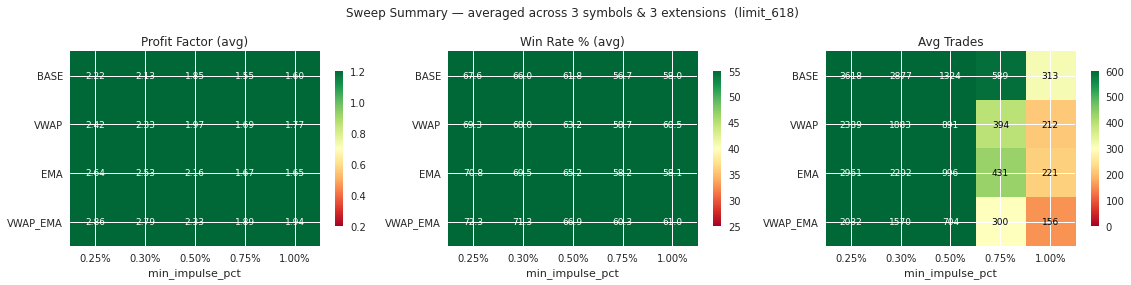

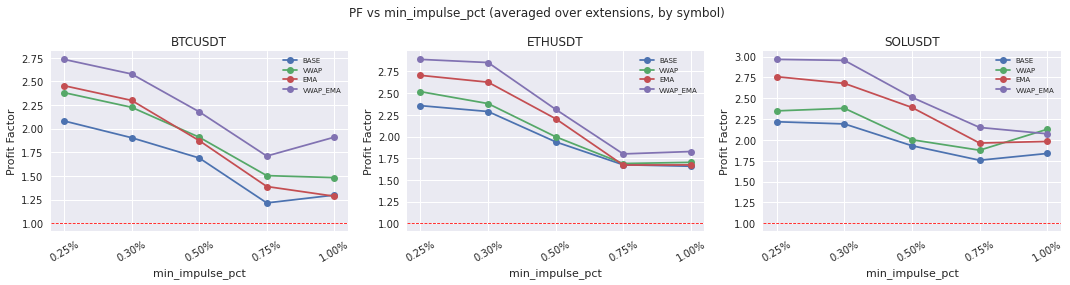

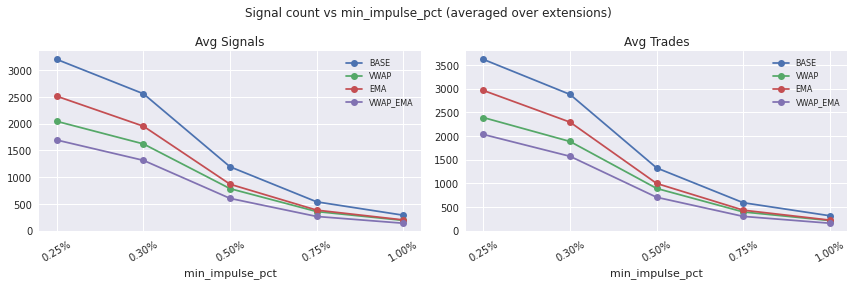

In [9]:
def _prep(r):
    t = r['trades'].copy()
    if t.empty: return t
    t['entry_time'] = pd.to_datetime(t['entry_time'])
    t['exit_time']  = pd.to_datetime(t['exit_time'])
    t = t.sort_values('entry_time').reset_index(drop=True)
    t['trade_number']  = range(1, len(t) + 1)
    t['cum_net_pnl']   = t['net_pnl'].cumsum()
    t['running_peak']  = t['cum_net_pnl'].cummax()
    t['drawdown']      = t['cum_net_pnl'] - t['running_peak']
    t['entry_hour']    = t['entry_time'].dt.strftime('%H:00')
    t['trade_date']    = t['entry_time'].dt.date
    return t


def _all_rows():
    """Flatten 4-level results dict into a DataFrame row per run."""
    rows = []
    for sym, variants in results.items():
        for variant, imps in variants.items():
            for imp_pct, exts in imps.items():
                for target_ext, r in exts.items():
                    s = build_backtest_summary(r['trades'], r['daily_pnl'])
                    rows.append(dict(sym=sym, variant=variant, imp_pct=imp_pct,
                                     target_ext=target_ext,
                                     pf=s['profit_factor'], win_pct=s['win_rate'],
                                     net=s['net_pnl'], trades=s['total_trades'],
                                     signals=len(r['selected_strategy_signals'])))
    return pd.DataFrame(rows)


# ── Plot 1: Heatmap — variant × impulse_pct, averaged across symbols & extensions
def plot_sweep_heatmap():
    if not results: return
    df = _all_rows()
    variants   = list(STRATEGY_VARIANTS.keys())
    imp_labels = [f'{v:.2f}%' for v in IMPULSE_PCT_SWEEP]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Sweep Summary — averaged across {len(results)} symbols & {len(TARGET_EXT_SWEEP)} extensions  ({ENTRY_MODE})', fontsize=12)

    for ax, metric, label, lo, hi, fmt in [
        (axes[0], 'pf',      'Profit Factor (avg)',  0.2,  1.2,  '{:.2f}'),
        (axes[1], 'win_pct', 'Win Rate % (avg)',     25.0, 55.0, '{:.1f}'),
        (axes[2], 'trades',  'Avg Trades',            0,   600,  '{:.0f}'),
    ]:
        mat = (df.groupby(['variant', 'imp_pct'])[metric]
               .mean()
               .unstack('imp_pct')
               .reindex(index=variants, columns=IMPULSE_PCT_SWEEP))
        vals = mat.values.astype(float)
        im = ax.imshow(vals, cmap='RdYlGn', aspect='auto', vmin=lo, vmax=hi)
        ax.set_xticks(range(len(IMPULSE_PCT_SWEEP))); ax.set_xticklabels(imp_labels)
        ax.set_yticks(range(len(variants)));           ax.set_yticklabels(variants)
        ax.set_xlabel('min_impulse_pct'); ax.set_title(label)
        for i in range(len(variants)):
            for j in range(len(IMPULSE_PCT_SWEEP)):
                v = vals[i, j]
                if not pd.isna(v):
                    ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=9,
                            color='black' if 0.25 < im.norm(v) < 0.85 else 'white')
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()


# ── Plot 2: PF vs impulse_pct line chart — averaged over extensions, one line per variant
def plot_pf_vs_impulse():
    if not results: return
    syms = list(results.keys())
    n    = len(syms)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    fig.suptitle('PF vs min_impulse_pct (averaged over extensions, by symbol)', fontsize=12)
    imp_labels = [f'{v:.2f}%' for v in IMPULSE_PCT_SWEEP]
    for col, sym in enumerate(syms):
        ax = axes[0][col]
        for variant in STRATEGY_VARIANTS:
            pfs = []
            for ip in IMPULSE_PCT_SWEEP:
                ext_pfs = [build_backtest_summary(results[sym][variant][ip][ext]['trades'],
                                                  results[sym][variant][ip][ext]['daily_pnl'])['profit_factor']
                           for ext in TARGET_EXT_SWEEP]
                pfs.append(sum(ext_pfs) / len(ext_pfs))
            ax.plot(imp_labels, pfs, marker='o', label=variant)
        ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(sym); ax.set_xlabel('min_impulse_pct'); ax.set_ylabel('Profit Factor')
        ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()


# ── Plot 3: Trade count vs impulse_pct (shows how aggressively signals are cut)
def plot_signals_vs_impulse():
    if not results: return
    df = _all_rows()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Signal count vs min_impulse_pct (averaged over extensions)', fontsize=12)
    avg = df.groupby(['variant', 'imp_pct'])[['signals', 'trades']].mean().reset_index()
    for ax, col, title in [(axes[0], 'signals', 'Avg Signals'), (axes[1], 'trades', 'Avg Trades')]:
        for variant in STRATEGY_VARIANTS:
            sub = avg[avg['variant'] == variant].sort_values('imp_pct')
            ax.plot([f'{v:.2f}%' for v in sub['imp_pct']], sub[col], marker='o', label=variant)
        ax.set_title(title); ax.set_xlabel('min_impulse_pct'); ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()


plot_sweep_heatmap()
plot_pf_vs_impulse()
plot_signals_vs_impulse()


## Trade Inspector

Set `INSPECT_SYM` and optionally `INSPECT_DATE` (None = worst-PnL day).

In [10]:
INSPECT_SYM      = list(results.keys())[0] if results else None
INSPECT_VARIANT  = 'VWAP_EMA'      # BASE / VWAP / EMA / VWAP_EMA
INSPECT_IMP_PCT  = 0.25            # one of IMPULSE_PCT_SWEEP values
INSPECT_TARGET_EXT = 1.272         # one of TARGET_EXT_SWEEP values
INSPECT_DATE     = None            # e.g. '2026-04-01'  (None = worst-PnL day)


def plot_trade_day(sym, variant, imp_pct, target_ext, trade_date=None):
    r = results.get(sym, {}).get(variant, {}).get(imp_pct, {}).get(target_ext)
    if not r:
        print(f'No result for {sym}/{variant}/imp={imp_pct}/ext={target_ext}'); return
    t = _prep(r)
    if t.empty:
        print(f'No trades for {sym}/{variant}/imp={imp_pct}/ext={target_ext}'); return

    if trade_date is None:
        trade_date = t.loc[t['net_pnl'].abs().idxmax(), 'trade_date']

    mkt   = r['_market_data']
    dsym  = mkt['symbol'].iloc[0]
    day_d = mkt[(mkt['symbol'] == dsym) & (mkt['trade_date'] == str(trade_date))]
    day_t = t[t['trade_date'] == pd.Timestamp(trade_date).date()]

    if day_d.empty:
        print(f'No market data for {sym} on {trade_date}'); return

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})
    trail_label = f'trailing=ON ext={target_ext}' if USE_TRAILING_STOP else f'trailing=OFF ext={target_ext}'
    fig.suptitle(f'{sym}  BOS_FIB_{variant}  imp={imp_pct}%  {trail_label}  {trade_date}  ({len(day_t)} trades)', fontsize=13)

    ax = axes[0]
    ax.plot(day_d['timestamp'], day_d['close'], color='black', linewidth=1.0)
    longs  = day_t[day_t['side'] == 'LONG']
    shorts = day_t[day_t['side'] == 'SHORT']
    ax.scatter(longs['entry_time'],  longs['entry_price'],  marker='^', s=100, color='green', zorder=5, label='Long')
    ax.scatter(shorts['entry_time'], shorts['entry_price'], marker='v', s=100, color='red',   zorder=5, label='Short')
    ax.scatter(day_t['exit_time'],   day_t['exit_price'],   marker='x', s=80,  color='blue',  zorder=5, label='Exit')
    for _, tr in day_t.iterrows():
        color = 'green' if tr['net_pnl'] > 0 else (
            'orange' if tr['exit_reason'] in ('trail_stop', 'partial_target') else 'red'
        )
        ax.plot([tr['entry_time'], tr['exit_time']], [tr['entry_price'], tr['exit_price']],
                color=color, linewidth=0.8, alpha=0.6)
    ax.set_ylabel('Price'); ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

    axes[1].bar(range(len(day_t)), day_t['net_pnl'],
                color=['green' if v > 0 else 'red' for v in day_t['net_pnl']])
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Trade #'); axes[1].set_ylabel('Net PnL')
    plt.tight_layout(); plt.show()
    display(day_t[['entry_time','side','entry_price','exit_price','exit_reason','gross_pnl','net_pnl']])


if INSPECT_SYM:
    plot_trade_day(INSPECT_SYM, INSPECT_VARIANT, INSPECT_IMP_PCT, INSPECT_TARGET_EXT, INSPECT_DATE)


No market data for BTCUSDT on 2026-06-05


## Signal & Hourly Detail (per symbol)

In [11]:
for sym, variants in results.items():
    print(f"\n{'='*70}")
    print(f"{sym}")
    for variant, imps in variants.items():
        for imp_pct, exts in imps.items():
            for target_ext, r in exts.items():
                sigs = r['selected_strategy_signals']
                print(f"\n  ── BOS_FIB_{variant}  imp={imp_pct}%  ext={target_ext}  ({len(sigs)} signals) ──")
                display(strategy_summary(r['trades']))
                display(hourly_summary(r['trades']))



BTCUSDT

  ── BOS_FIB_BASE  imp=0.5%  ext=1.0  (651 signals) ──


,strategy_name,trades,gross_pnl,net_pnl,win_rate
0,BOS_FIB_BASE,862,2407.202526,2407.202526,65.661253


,entry_hour,trades,gross_pnl,net_pnl,win_rate
0,00:00,34,92.287880,92.287880,64.705882
1,01:00,36,216.619358,216.619358,77.777778
2,02:00,20,36.416369,36.416369,60.000000
3,03:00,36,221.201166,221.201166,75.000000
4,04:00,53,252.991086,252.991086,73.584906
5,05:00,29,-3.775976,-3.775976,58.620690
6,06:00,31,4.574847,4.574847,54.838710
7,07:00,31,-12.351617,-12.351617,54.838710
8,08:00,22,33.908871,33.908871,63.636364
9,09:00,29,110.297772,110.297772,65.517241



  ── BOS_FIB_BASE  imp=0.5%  ext=1.272  (652 signals) ──


,strategy_name,trades,gross_pnl,net_pnl,win_rate
0,BOS_FIB_BASE,694,3294.408434,3294.408434,56.772334


...

,strategy_name,trades,gross_pnl,net_pnl,win_rate
0,BOS_FIB_VWAP_EMA,211,2613.713094,2613.713094,61.137441


,entry_hour,trades,gross_pnl,net_pnl,win_rate
0,00:00,7,83.390919,83.390919,57.142857
1,01:00,8,182.448933,182.448933,62.500000
2,02:00,9,-129.870433,-129.870433,22.222222
3,03:00,8,66.795845,66.795845,62.500000
4,04:00,12,288.762695,288.762695,91.666667
5,05:00,8,101.162601,101.162601,62.500000
6,06:00,9,99.244777,99.244777,66.666667
7,07:00,9,345.336758,345.336758,77.777778
8,08:00,9,223.135287,223.135287,77.777778
9,09:00,5,-41.844286,-41.844286,40.000000



  ── BOS_FIB_VWAP_EMA  imp=1.0%  ext=1.618  (198 signals) ──


,strategy_name,trades,gross_pnl,net_pnl,win_rate
0,BOS_FIB_VWAP_EMA,197,2810.198445,2810.198445,58.375635


,entry_hour,trades,gross_pnl,net_pnl,win_rate
0,00:00,7,83.390919,83.390919,57.142857
1,01:00,8,226.269407,226.269407,62.500000
2,02:00,9,-129.870433,-129.870433,22.222222
3,03:00,8,66.795845,66.795845,62.500000
4,04:00,10,288.762695,288.762695,90.000000
5,05:00,8,142.963698,142.963698,62.500000
6,06:00,8,99.244777,99.244777,62.500000
7,07:00,8,345.336758,345.336758,75.000000
8,08:00,8,223.135287,223.135287,75.000000
9,09:00,4,-41.844286,-41.844286,25.000000
